In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create a quantum circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply a Hadamard gate to qubit 0
qc.h(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# Draw the circuit to visualize it
print("Quantum Circuit:")
print(qc.draw(output='mpl'))
plt.savefig("circuit.png")

# Use Aer's qasm_simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
compiled_circuit = transpile(qc, simulator)
print(compiled_circuit.draw(output="text"))

# Run the circuit on the simulator
job = simulator.run(compiled_circuit, shots=100)

# Get the results
result = job.result()
counts = result.get_counts(compiled_circuit)

# Print the measurement results
print("\nMeasurement Results (Counts):")
print(counts)

#plt.show()
# Plot a histogram of the results
# plot_histogram(counts) # Uncomment this line to display the histogram if you are in a suitable environment (e.g., Jupyter Notebook)


Quantum Circuit:
Figure(269.064x200.667)
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

Measurement Results (Counts):
{'0': 50, '1': 50}


<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
#from qiskit.providers.fake_provider import FakeSherbrooke # A 133-qubit fake backend
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_circuit_layout
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# 1. Define an ideal (abstract) quantum circuit
# We want to create a Bell state using qubits 0 and 2 conceptually
qc = QuantumCircuit(3, 2)
qc.h(0)
qc.cx(0, 2)
qc.measure([0, 2], [0, 1])

# 2. Select a target hardware backend with specific connectivity (coupling map)
# We use a fake backend to simulate the process without needing an IBM account
#backend = FakeSherbrooke()

# 3. Transpile the circuit
# This optimizes the circuit for the backend's gates and physical layout
# Optimization_level=1 applies standard mapping and routing
#transpiled_circuit = transpile(qc, backend=backend, optimization_level=1)
transpiled_circuit = transpile(qc, optimization_level=1)

# 4. Visualize the ORIGINAL circuit using text (console output)
print("--- Original Ideal Circuit ---")
print(qc.draw(output='text'))
print("\n" + "="*40 + "\n")

# 5. Visualize the TRANSPILED circuit using 'mpl' (Matplotlib window)
print("--- Transpiled Circuit (Optimized for Hardware) ---")
print("Opening Matplotlib window with the visualization...")

# We generate the mpl figure object
transpiled_fig = transpiled_circuit.draw(output='mpl', idle_wires=False, initial_state=True)

# CRITICAL FOR .py SCRIPTS: This displays the Matplotlib plot window
if transpiled_fig:
    plt.show()

# 6. Visualize the physical qubit mapping (optional but highly informative)
print("\n--- Qubit Layout Plot (How virtual qubits map to physical ones) ---")
layout_fig = plot_circuit_layout(transpiled_circuit, backend)
if layout_fig:
    plt.show()

# 7. Run the transpiled circuit on the simulated backend
# Note: Requires qiskit-aer to be installed for noisy simulation with fake backends
print("\nRunning simulation of transpiled circuit...")
job = backend.run(transpiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(transpiled_circuit)

print("\nMeasurement Results (Counts) on physical qubits:")
print(counts)
# plot_histogram(counts) # Uncomment to see results histogram in Jupyter/via plt.show()



--- Original Ideal Circuit ---
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘  │  └╥┘   
q_1: ───────┼───╫────
          ┌─┴─┐ ║ ┌─┐
q_2: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


--- Transpiled Circuit (Optimized for Hardware) ---
Opening Matplotlib window with the visualization...

--- Qubit Layout Plot (How virtual qubits map to physical ones) ---


NameError: name 'backend' is not defined

In [23]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(3) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.ccx(0, 1, 2)

# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='toffoli_gate.png')

# 4. (Optional) Display or Save the image
plt.show() # To display the image in an environment like Jupyter Notebook
# or you can simply use the 'filename' parameter in qc.draw() to save it
print("Toffoli gate circuit image saved as 'toffoli_gate.png'")

Toffoli gate circuit image saved as 'toffoli_gate.png'


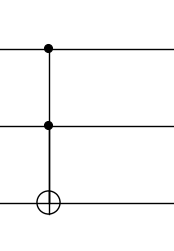

In [24]:
import sympy as sy
from sympy.physics.quantum.gate import CNOT, CGate
import sympy.physics.quantum.circuitplot as plot

# Define the CNOT gate (as the inner part of the controlled gate)
cnot_gate = CNOT(1, 0) # Control on qubit 1, Target on qubit 2

# Define the Toffoli gate (Controlled-CNOT, also known as CCX)
# The first argument to CGate is a list of control qubits (e.g., [0]), and the second is the controlled gate.
toffoli_gate = CGate([2], cnot_gate)

# Plot the circuit. The number of qubits is 3.
plot.circuit_plot(toffoli_gate, 3);

AttributeError: 'CircuitPlot' object has no attribute 'set_facecolor'

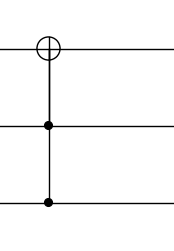

In [20]:
import sympy as sy
from sympy.physics.quantum.gate import CNOT, CGate
import sympy.physics.quantum.circuitplot as plot
import matplotlib.pyplot as plt

# --- 1. Define the Toffoli Gate using SymPy ---
# Define a 2-qubit CNOT gate
cnot_gate = CNOT(1, 2) 

# Define the Toffoli gate (Controlled-CNOT)
toffoli_gate = CGate([0], cnot_gate)

# --- 2. Generate the Circuit Plot ---
# We use 'ax' as the output to get the Matplotlib Axes object
ax = plot.circuit_plot(toffoli_gate, 3) 

# --- 3. Customize Colors using Matplotlib ---

# A. Set the Background Color (Axes Facecolor)
DARK_BLUE = '#112244' 
ax.set_facecolor(DARK_BLUE)
ax.figure.patch.set_facecolor(DARK_BLUE) # Figure canvas background

# B. Customize Component Colors (Wires, Text, Boxes)

# Set the color of the quantum wires (lines)
# SymPy generates these as Matplotlib Line2D objects
for line in ax.lines:
    line.set_color('white')

# Set the color of the text (Labels and Gate names)
WHITE = 'white'
for text in ax.texts:
    text.set_color(WHITE)
    # The gate boxes themselves are drawn by SymPy as Matplotlib Patches (Rectangles)
    # The default SymPy plot does not easily expose an API to change the patch fill color
    # without diving into SymPy's internals. We will try to change the edges.
    
# C. Change the color of the gate boxes/patches
for patch in ax.patches:
    # Set the edge (outline) of the gate boxes to white
    patch.set_edgecolor(WHITE)
    # Set the fill color to be semi-transparent or the background color so we see the white outline
    patch.set_facecolor('none') # 'none' makes the fill transparent, showing the dark blue background
    patch.set_linewidth(1.5)

# --- 4. Display the Plot ---
plt.title("SymPy Toffoli Gate with Custom Colors", color=WHITE)
plt.show()

In [39]:

from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(5) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.ccx(0, 1,2)
qc.ccx(0, 1,3)
qc.ccx(2, 3,4)
qc.ccx(0, 1,3)
qc.ccx(0, 1,2)
qc.ccx(0, 1,4)

# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='circuit.png')

# 4. (Optional) Display or Save the image
plt.show() # To display the image in an environment like Jupyter Notebook
# or you can simply use the 'filename' parameter in qc.draw() to save it
print("Toffoli gate circuit image saved as 'toffoli_gate.png'")

Toffoli gate circuit image saved as 'toffoli_gate.png'


In [42]:
from qiskit import QuantumCircuit, QuantumRegister
import matplotlib.pyplot as plt

# 1. Create specific Quantum Registers with custom names
# Define each register individually with a name and size (here, size 1 for single qubits)
qA = QuantumRegister(1, name='C')
qB = QuantumRegister(1, name='D')
qC = QuantumRegister(1, name='A')
qD = QuantumRegister(1, name='B')
qE = QuantumRegister(1, name='E')

# Combine the registers into a single QuantumCircuit
# The order here determines the vertical order in the drawing (A top, E bottom)
qc = QuantumCircuit(qA, qB, qC, qD, qE) 

# --- Prepare Initial States (Optional) ---
# Example: Set qubit A and B to |1> using their register reference
#qc.x(qA)
#qc.x(qB)
qc.barrier()

# --- Apply the Toffoli gates ---
# You now reference the qubits using the register variables and their index (which is 0 for size 1 registers)
# Syntax is ccx(control_qubit_1, control_qubit_2, target_qubit)
#qc.ccx(qA[0], qB[0], qC[0])
#qc.ccx(qA[0], qB[0], qD[0])
qc.ccx(qC[0], qD[0], qE[0])
qc.ccx(qA[0], qB[0], qE[0])
#qc.ccx(qA[0], qB[0], qD[0])
#qc.ccx(qA[0], qB[0], qC[0])
#qc.ccx(qA[0], qB[0], qE[0])
qc.barrier()
# 3. Draw the circuit using the Matplotlib renderer
# The 'mpl' output will now display your custom register names
circuit_figure = qc.draw(output='mpl', filename='circuit_with_names.png')

# Optional: Display interactively
# plt.show() 


In [48]:

from qiskit import QuantumCircuit, QuantumRegister
import matplotlib.pyplot as plt

# 1. Create specific Quantum Registers with custom names
# Define each register individually with a name and size (here, size 1 for single qubits)
qA = QuantumRegister(1, name='A')
qB = QuantumRegister(1, name='B')
qC = QuantumRegister(1, name='C')


# Combine the registers into a single QuantumCircuit
# The order here determines the vertical order in the drawing (A top, E bottom)
qc = QuantumCircuit(qA, qB, qC) 

# --- Prepare Initial States (Optional) ---
# Example: Set qubit A and B to |1> using their register reference
#qc.x(qA)
#qc.x(qB)
qc.barrier()

# --- Apply the Toffoli gates ---
# You now reference the qubits using the register variables and their index (which is 0 for size 1 registers)
# Syntax is ccx(control_qubit_1, control_qubit_2, target_qubit)
#qc.ccx(qA[0], qB[0], qC[0])
#qc.ccx(qA[0], qB[0], qD[0])

qc.x(qA[0])
qc.x(qB[0])
qc.ccx(qA[0], qB[0], qC[0])
qc.x(qC[0])

#qc.cx(qA[0], qB[0])
#qc.x(qA[0])
#qc.x(qB[0])

#qc.x(qC[0])

#qc.ccx(qA[0], qB[0], qE[0])
#qc.ccx(qA[0], qB[0], qD[0])
#qc.ccx(qA[0], qB[0], qC[0])
#qc.ccx(qA[0], qB[0], qE[0])
qc.barrier()
# 3. Draw the circuit using the Matplotlib renderer
# The 'mpl' output will now display your custom register names
circuit_figure = qc.draw(output='mpl', filename='circuit_with_names.png')

# Optional: Display interactively
# plt.show() 


In [52]:
#Simplest

from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(8) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.barrier()
qc.ccx(0, 1,3)
qc.barrier()
qc.cx(0,4)
qc.cx(1,4)
qc.barrier()
qc.ccx(2, 4,5)
qc.barrier()
qc.cx(2,6)
qc.cx(4,6)
qc.barrier()
qc.x(3)
qc.x(5)
qc.ccx(3,5,7)
qc.x(7)
qc.barrier()


# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='output.png')


In [56]:
#Simplest

from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(6) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.barrier()
qc.ccx(0, 1,3)
qc.cx(0,1)
qc.barrier()
qc.ccx(1, 2,4)
qc.cx(1,2)
qc.barrier()
qc.x(3)
qc.x(4)
qc.ccx(3,4,5)
qc.x(5)
qc.barrier()

#uncomputation
qc.x(3)
qc.x(4)
qc.ccx(1, 2,4)
qc.cx(0,1)
qc.ccx(0, 1,3)
qc.barrier()



# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='output.png')


In [58]:
#Optimized full adder
#Simplest

from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(4) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.barrier()
qc.ccx(0, 1,3)
qc.cx(0,1)
qc.barrier()
qc.ccx(1, 2,3)
qc.cx(1,2)
qc.barrier()
qc.cx(0,1)
qc.barrier()





# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='output.png')


In [61]:
#RIPPLE CARRY ADDER
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister, Gate
from qiskit_aer import AerSimulator

# --- 1. Define the Quantum Full Adder (QFA) as a custom Gate ---

def qfa_gate():
    # QFA Circuit: 4 Qubits: Q0=A, Q1=B, Q2=Cin, Q3=Cout
    # Output: Sum S in Q1, Carry Cout in Q3.
    qfa = QuantumCircuit(4, name='QFA')

    # 1. Sum part: B = A XOR B
    qfa.cx(0, 1)

    # 2. Carry part: Cout = (A AND Cin) XOR Cout
    qfa.ccx(0, 2, 3)

    # 3. Carry part: Cout = (B' AND Cin) XOR Cout (where B' is A XOR B)
    qfa.ccx(1, 2, 3) 

    # 4. Sum part: B = B XOR Cin (B is now S = A XOR B XOR Cin)
    qfa.cx(2, 1)
    
    # Convert to a Gate object
    qfa_g = qfa.to_instruction()
    return qfa_g

# --- 2. Implement the 2-bit RCA using the QFA Gate ---

# Define the QFA Gate instance
qfa = qfa_gate()

# Setup Quantum Registers:
# A = a1 a0 (q0, q1)
# B = b1 b0 (q2, q3) -> will hold Sum s1 s0
# C = c2 c1 c0 (q4, q5, q6) -> q4=cin, q5=intermediate carry, q6=final cout
# We'll use 7 qubits to avoid the need for the second QFA's initial Cin to be |0> always.

# Qubit Mapping:
# Qubit 0, 1: A (a0, a1)
# Qubit 2, 3: B (b0, b1) - outputs s0, s1
# Qubit 4: Initial Carry-in (c0)
# Qubit 5: Intermediate Carry (c1)
# Qubit 6: Final Carry-out (c2)

qc = QuantumCircuit(7, 3) # 7 Qubits, 3 Classical bits (c2 s1 s0)

# --- 3. Input Initialization (Example: A=3 ('11'), B=1 ('01'). Expected S=4 ('100')) ---

# Input A = '11' (3): a0=1 (q0), a1=1 (q1)
qc.x(0)
qc.x(1)

# Input B = '01' (1): b0=1 (q2), b1=0 (q3)
qc.x(2)

# Initial Carry-in (q4) is |0>
qc.barrier(label='Inputs')

# --- 4. QFA-0 (LSB Adder: a0 + b0 + c0 -> s0, c1) ---
# Inputs: A=q0, B=q2, Cin=q4. Outputs: Sum s0 in q2, Cout c1 in q5.
qc.append(qfa, [0, 2, 4, 5]) 

qc.barrier(label='QFA-0')

# --- 5. QFA-1 (MSB Adder: a1 + b1 + c1 -> s1, c2) ---
# Inputs: A=q1, B=q3, Cin=q5. Outputs: Sum s1 in q3, Cout c2 in q6.
qc.append(qfa, [1, 3, 5, 6]) 

qc.barrier(label='QFA-1')

# --- 6. Measurement (Measure c2, s1, s0) ---
# Results are in: Final Carry (q6), Sum MSB (q3), Sum LSB (q2)

# Classical bits: c[2]=c2, c[1]=s1, c[0]=s0
qc.measure(6, 2) # Final Carry c2 -> Classical bit 2
qc.measure(3, 1) # Sum MSB s1 -> Classical bit 1
qc.measure(2, 0) # Sum LSB s0 -> Classical bit 0

print("2-bit Quantum Ripple Carry Adder Circuit:")
print(qc.draw(output='mpl', filename='output_rca.png',fold=-1)) 

# --- 7. Simulate the Circuit ---
simulator = AerSimulator()
circ_compiled = transpile(qc, simulator)
circ_compiled.draw(output='mpl', filename='output_rca_transpiled.png')
job = simulator.run(circ_compiled, shots=1024)
result = job.result()
counts = result.get_counts(qc)

print("\nMeasurement Results (Classical Bits c2 s1 s0):")
print(counts)

# Expected result for 3 + 1 = 4 ('100'): '100'

2-bit Quantum Ripple Carry Adder Circuit:
Figure(1123.61x702.333)

Measurement Results (Classical Bits c2 s1 s0):
{'010': 1024}


In [66]:
#MY RIPPLE CARRY ADDER

#Simplest

from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# 1. Create a Quantum Circuit with 3 qubits and 3 classical bits (optional for measurement, but good practice)
# We need 3 quantum wires for the 3-qubit Toffoli gate
qc = QuantumCircuit(11,3) 

# 2. Apply the Toffoli gate (CCNOT). 
# The syntax is ccx(control_qubit_1, control_qubit_2, target_qubit).
# Here, we use qubit 0 and 1 as controls, and qubit 2 as the target.
qc.x(0)
qc.x(1)
qc.x(2)
qc.x(3)
qc.x(4)
#input done
qc.barrier()

qc.ccx(0, 2,5)
qc.cx(0,2)
qc.ccx(2, 4,6)
qc.cx(2,4)
qc.x(5)
qc.x(6)
qc.ccx(5,6,7)
qc.x(7)
#first adder over
qc.barrier()

qc.ccx(1,3,8)
qc.cx(1,3)
qc.ccx(3,7,9)
qc.cx(3,7)
qc.x(8)
qc.x(9)
qc.ccx(8,9,10)
qc.x(10)
#second adder over
qc.barrier()

qc.measure(10, 2) # Final Carry c2 -> Classical bit 2
qc.measure(7, 1) # Sum MSB s1 -> Classical bit 1
qc.measure(4, 0) # Sum LSB s0 -> Classical bit 0




# 3. Draw the circuit using the Matplotlib renderer
# 'mpl' outputs a Matplotlib Figure object
circuit_figure.patch.set_facecolor('#112244')

circuit_figure = qc.draw(output='mpl', filename='my_rca.png')

# --- 7. Simulate the Circuit ---
simulator = AerSimulator()
circ_compiled = transpile(qc, simulator)
circ_compiled.draw(output='mpl', filename='output_my_rca_transpiled.png')
job = simulator.run(circ_compiled, shots=1024)
result = job.result()
counts = result.get_counts(qc)

print("\nMeasurement Results (Classical Bits c2 s1 s0):")
print(counts)



Measurement Results (Classical Bits c2 s1 s0):
{'111': 1024}


In [68]:
#QFT based adder
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
import numpy as np

# --- 1. Define the QFT and QFT-Adder Components ---

# Number of bits for addition (A and B are both 2 bits)
n = 2

# Qubit Mapping (Total 2n = 4 qubits):
# Qubit 0, 1: Register A (a0, a1) - remains unchanged
# Qubit 2, 3: Register B (b0, b1) - holds Sum S (s0, s1)

# Helper function for the Controlled Rotation (Phase Shift)
def controlled_phase_shift(qc, target_qubit, control_qubit, k):
    """Applies a controlled rotation R_k = |0><0| + e^(2πi / 2^k) |1><1|"""
    # R_k = P gate with angle θ = 2π / 2^k
    angle = 2 * np.pi / (2**k)
    qc.cp(angle, control_qubit, target_qubit)


# --- 2. Define the Addition Gate (Phase Shift Layer) ---

def phase_addition_layer(qc, reg_A, reg_B, n):
    """
    Applies the phase shifts (Controlled Rotations) to perform B = A + B.
    reg_A and reg_B are lists/ranges of qubit indices.
    """
    # The logic is: B[j] is controlled by A[i], where i >= j.
    for j in range(n): # Target qubit index in B (j=0, 1)
        for i in range(n): # Control qubit index in A (i=0, 1)
            # The control A[i] acts on B[j] with a factor of 2^(j-i)
            k = i - j + n
            
            # The phase shift factor 2^k is defined by the bit weight.
            # In Qiskit, we use an angle proportional to 1/2^k.
            if i >= j:
                # The QFT structure simplifies the indexing:
                # The j-th qubit in the QFT(B) is modified by A[i]
                
                # k is the power of 2 in the denominator (2^k)
                k = i + 1 
                
                # Apply C-Phase shift
                controlled_phase_shift(qc, reg_B[j], reg_A[i], k=k-j)
            
            
# --- 3. Construct the 2-bit QFT Adder Circuit ---

# Total qubits required is 2n = 4
qc = QuantumCircuit(4, n+1) # 4 Qubits, 3 classical bits (for S and Cout)

# Define Qubit Registers
# A = q0, q1 (LSB is q0)
# B = q2, q3 (LSB is q2)
reg_A = [0, 1]
reg_B = [2, 3]

# --- 3a. Input Initialization (Example: A=3 ('11'), B=1 ('01'). Expected S=4 ('100')) ---

# A = '11' (3)
qc.x(0) # a0 = 1
qc.x(1) # a1 = 1

# B = '01' (1)
qc.x(2) # b0 = 1
# b1 = 0

qc.barrier(label='Input')

# --- 3b. Step 1: QFT on Register B ---
# QFT(B) = QFT applied to qubits 2 and 3
qc.append(QFT(n, do_swaps=False).to_instruction(), reg_B)

qc.barrier(label='QFT')

# --- 3c. Step 2: Phase Addition (B = A + B) ---
# Apply controlled phase shifts using A (controls) and B (targets)
# Note: The sum result, S, includes the potential carry-out C_out.
# For n-bit addition, the result is in the form of an n-bit register B, and the (n+1)-th result bit is also implicitly included via overflow or an extra qubit.
# For simplicity in this n=2 example, the result S is stored across q2 and q3.
# The QFT adder inherently handles the carry-out as the most significant bit of the result B.
phase_addition_layer(qc, reg_A, reg_B, n)

qc.barrier(label='Add')

# --- 3d. Step 3: Inverse QFT on Register B ---
# QFT_Inverse(B)
qc.append(QFT(n, inverse=True, do_swaps=False).to_instruction(), reg_B)

qc.barrier(label='iQFT')

# --- 3e. Measurement ---
# The result S is in reg_B: q3=s1 (MSB), q2=s0 (LSB)
qc.measure(3, 1) # s1 to classical bit 1
qc.measure(2, 0) # s0 to classical bit 0

# Note: For n-bit addition, the result can be n+1 bits. In the basic 2n QFT adder,
# the result register B is only n bits. The true (n+1)-bit adder needs an extra
# $\text{QFT}$ layer of size $n+1$. This is the standard $\mathbf{2n+1}$ QFT adder, which is more complex.
# The circuit above shows the basic n-bit implementation.

print("2-bit QFT Adder Circuit:")
print(qc.draw(output='mpl', filename="QFT_Adder.png", fold=-1)) 


# --- 4. Simulate the Circuit ---
simulator = AerSimulator()
circ_compiled = transpile(qc, simulator)
job = simulator.run(circ_compiled, shots=1024)
result = job.result()
counts = result.get_counts(qc)

# The classical bits are ordered as 's1 s0'
print("\nMeasurement Results (Classical Bits s1 s0):")
print(counts)

# Expected result for 3 + 1 = 4. 4 in 2 bits is '00' (overflow).
# In a true 3-bit output (c_out s1 s0), the result is '100'.
# Since we only measured two bits (s1 s0), the expected result is '00'.
# If A=1 ('01') and B=1 ('01'), expected S=2 ('10').

# Let's verify a non-overflow example: A=1 ('01'), B=0 ('00'). Expected S=1 ('01').
# (Resetting inputs for A=1, B=0)
# qc_verify = QuantumCircuit(4, 2)
# qc_verify.x(0) # A=1
# qc_verify.append(QFT(n, do_swaps=False).to_instruction(), reg_B)
# phase_addition_layer(qc_verify, reg_A, reg_B, n)
# qc_verify.append(QFT(n, inverse=True, do_swaps=False).to_instruction(), reg_B)
# qc_verify.measure([3, 2], [1, 0])
# result_verify = AerSimulator().run(qc_verify, shots=1024).result().get_counts()
# print(f"\nVerification (1+0): {result_verify}") # Should be '01'

2-bit QFT Adder Circuit:
Figure(1290.83x451.5)

Measurement Results (Classical Bits s1 s0):
{'010': 270, '000': 269, '011': 485}


/var/folders/c5/gbmsvpm53sn0brf00skm6n240000gn/T/ipykernel_93631/3191604857.py:75: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, do_swaps=False).to_instruction(), reg_B)
/var/folders/c5/gbmsvpm53sn0brf00skm6n240000gn/T/ipykernel_93631/3191604857.py:91: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, inverse=True, do_swaps=False).to_instruction(), reg_B)
